In [1]:
import pandas as pd
import os

# 1. Define paths relative to the notebooks directory
RAW_DATA_PATH = "../data/raw/BDKR81DT/BDKR81FL.DTA"
PROCESSED_DATA_PATH = "../data/processed/bdhs_2022_cleaned.csv"

print("Loading raw Stata dataset...")
# Reading with categorical conversion to preserve the text labels (e.g., 'Poorest', 'Urban')
df_raw = pd.read_stata(RAW_DATA_PATH, convert_categoricals=True)

# 2. Filter for valid deliveries (Drop rows where C-section status is missing)
df_valid = df_raw.dropna(subset=['m17']).copy()

# 3. Map DHS codes to the readable feature names defined in your methodology
column_mapping = {
    'm17': 'c_section',          # Target
    'v012': 'mothers_age',       # Mother's age
    'v106': 'education',         # Highest educational level
    'v190': 'wealth_index',      # Wealth index quintile
    'v025': 'residence_type',    # Urban/Rural
    'v024': 'region',            # Geographic division
    'm14': 'anc_visits',         # Prenatal checkups
    'm15': 'delivery_place',     # Type of hospital/clinic
    'bord': 'birth_order'        # Parity
}

# Ensure columns exist before filtering
available_cols = {k: v for k, v in column_mapping.items() if k in df_valid.columns}
df_clean = df_valid[list(available_cols.keys())].rename(columns=available_cols)

# 4. Convert the target variable into binary for ML algorithms (1 = C-Section, 0 = Vaginal)
df_clean['c_section'] = df_clean['c_section'].apply(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0
)

# 5. Save the cleaned baseline dataset
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"\nSuccess! Processed data saved to: {PROCESSED_DATA_PATH}")
print(f"Final Dataset Shape: {df_clean.shape}")
print("\nFirst 5 rows of the processed dataset:")
display(df_clean.head())

Loading raw Stata dataset...

Success! Processed data saved to: ../data/processed/bdhs_2022_cleaned.csv
Final Dataset Shape: (5331, 9)

First 5 rows of the processed dataset:


,c_section,mothers_age,education,wealth_index,residence_type,region,anc_visits,delivery_place,birth_order
0,1,37,higher,richer,urban,barishal,9.0,private clinic,3
1,1,19,secondary,richer,urban,barishal,3.0,uh & family welfare center,1
3,1,30,higher,richest,urban,barishal,5.0,private clinic,1
6,1,26,higher,richer,urban,barishal,7.0,district hospital,2
7,0,22,higher,richest,urban,barishal,7.0,private clinic,1


In [3]:
import pandas as pd
import numpy as np

# Load processed data
df = pd.read_csv("../data/processed/bdhs_2022_cleaned.csv")

# 1. Group delivery places into clean standard categories
def categorize_delivery_place(val):
    val_str = str(val).lower()
    if 'home' in val_str or 'respondent' in val_str:
        return 'Home'
    elif 'private' in val_str or 'clinic' in val_str:
        return 'Private Facility'
    elif 'public' in val_str or 'gov' in val_str or 'hospital' in val_str or 'upazila' in val_str:
        return 'Public Facility'
    elif 'ngo' in val_str:
        return 'NGO Facility'
    return 'Other/Unknown'

df['delivery_facility_group'] = df['delivery_place'].apply(categorize_delivery_place)

# 2. Check and clean special survey missing values (e.g., 99 in anc_visits)
# In DHS, codes like 98 or 99 denote 'don't know' or 'missing'
# Force the column to numeric. Any text like "don't know" automatically becomes NaN
df['anc_visits'] = pd.to_numeric(df['anc_visits'], errors='coerce')

# Now apply the filter for DHS special codes (98, 99) and fill with the median
df['anc_visits'] = df['anc_visits'].apply(lambda x: np.nan if x > 40 else x)
df['anc_visits'] = df['anc_visits'].fillna(df['anc_visits'].median())
# Save updated cleaned dataset
df.to_csv("../data/processed/bdhs_2022_cleaned_v2.csv", index=False)
print("Data cleaning complete. Summary of delivery facilities:")
print(df['delivery_facility_group'].value_counts())

Data cleaning complete. Summary of delivery facilities:
delivery_facility_group
Private Facility    2504
Home                1923
Public Facility      723
Other/Unknown        181
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_16380\353460668.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


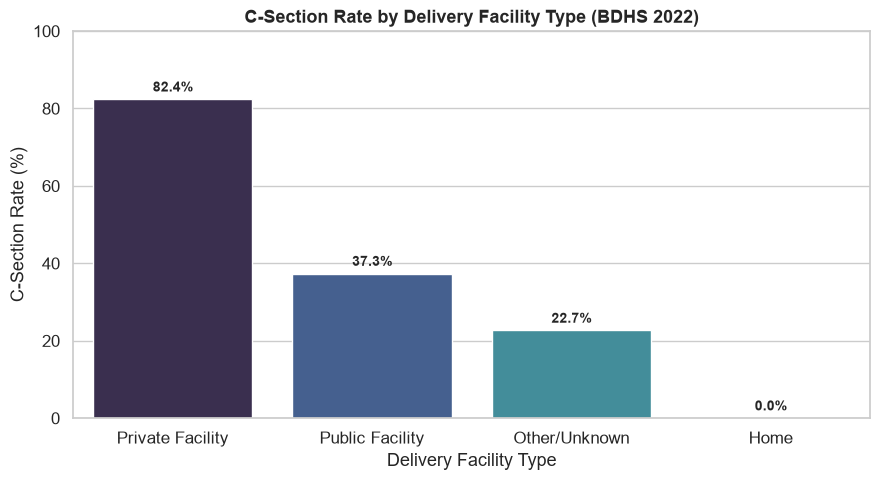

C:\Users\USER\AppData\Local\Temp\ipykernel_16380\353460668.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax2 = sns.barplot(


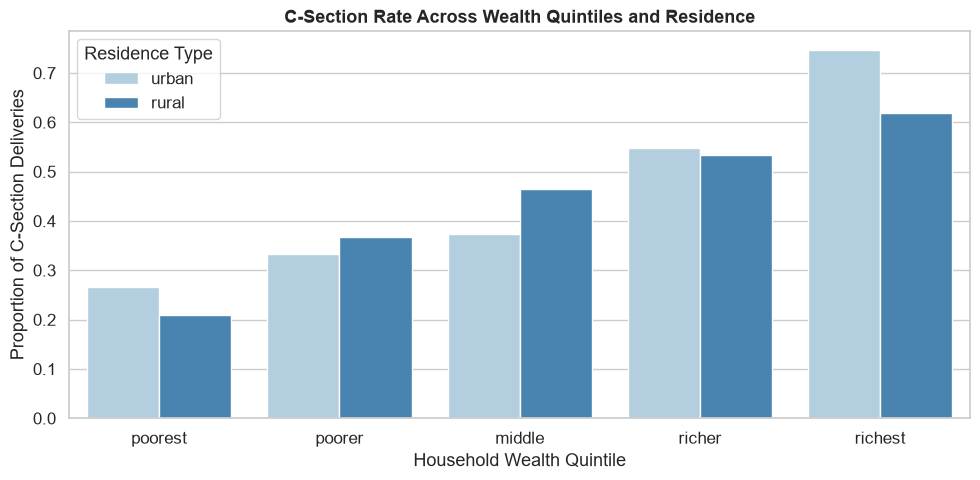

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../figures", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

# Figure 1: C-Section Rate by Delivery Facility Type (Core Thesis Hypothesis)
plt.figure(figsize=(9, 5))
facility_rates = df.groupby('delivery_facility_group')['c_section'].mean().reset_index()
facility_rates['c_section_pct'] = facility_rates['c_section'] * 100

ax1 = sns.barplot(
    data=facility_rates.sort_values(by='c_section_pct', ascending=False),
    x='delivery_facility_group', y='c_section_pct', palette='mako'
)
plt.title("C-Section Rate by Delivery Facility Type (BDHS 2022)", fontsize=13, weight='bold')
plt.ylabel("C-Section Rate (%)")
plt.xlabel("Delivery Facility Type")
plt.ylim(0, 100)
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                 ha='center', va='baseline', fontsize=10, weight='bold')
plt.tight_layout()
plt.savefig("../figures/fig1_facility_csection_rate.png", dpi=300)
plt.show()

# Figure 2: C-Section Disparity Across Wealth Quintiles & Residence
plt.figure(figsize=(10, 5))
wealth_order = ['poorest', 'poorer', 'middle', 'richer', 'richest']
# Ensure case matching
df['wealth_index_lower'] = df['wealth_index'].str.lower()

ax2 = sns.barplot(
    data=df, x='wealth_index_lower', y='c_section', hue='residence_type',
    order=wealth_order, ci=None, palette='Blues'
)
plt.title("C-Section Rate Across Wealth Quintiles and Residence", fontsize=13, weight='bold')
plt.ylabel("Proportion of C-Section Deliveries")
plt.xlabel("Household Wealth Quintile")
plt.legend(title="Residence Type")
plt.tight_layout()
plt.savefig("../figures/fig2_wealth_residence_trends.png", dpi=300)
plt.show()

findfont: Failed to find font weight 500, now using 400.


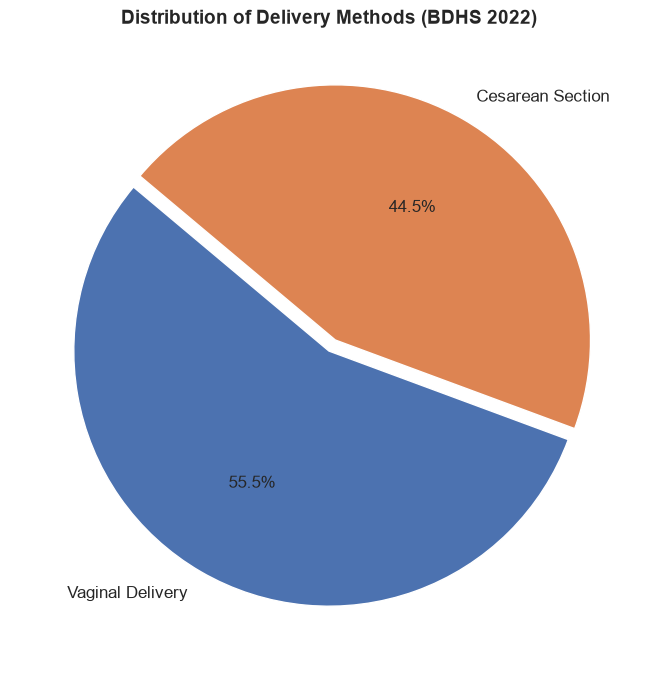

In [5]:
# Figure 3: Class Distribution of Delivery Methods (Target Variable)
plt.figure(figsize=(7, 7))

# Get the counts for 0 (Vaginal) and 1 (C-Section)
class_counts = df['c_section'].value_counts()

# Define labels ensuring they map correctly to the index (0 and 1)
label_map = {0: 'Vaginal Delivery', 1: 'Cesarean Section'}
labels = [label_map[idx] for idx in class_counts.index]

# Create the pie chart
plt.pie(
    class_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#4C72B0', '#DD8452'], # Professional, academic color palette
    explode=(0, 0.05),             # Slightly pop out the second slice for emphasis
    shadow=False,
    textprops={'fontsize': 12, 'weight': '500'}
)

plt.title("Distribution of Delivery Methods (BDHS 2022)", fontsize=14, weight='bold')
plt.tight_layout()

# Save the figure securely in your repository
plt.savefig("../figures/fig3_class_distribution.png", dpi=300)
plt.show()

In [6]:
import pandas as pd

# 1. Load the dataset we just cleaned
df = pd.read_csv("../data/processed/bdhs_2022_cleaned_v2.csv")

# 2. Final NaN check
print("Missing values before final drop:")
print(df.isnull().sum())

# Drop any lingering rows with NaNs to ensure strict compatibility with Scikit-Learn
df_clean = df.dropna().copy()

# Drop the old 'delivery_place' column since we now use 'delivery_facility_group'
if 'delivery_place' in df_clean.columns:
    df_clean = df_clean.drop(columns=['delivery_place'])

# 3. Define the categorical columns to encode
categorical_cols = [
    'education', 
    'wealth_index', 
    'residence_type', 
    'region', 
    'delivery_facility_group'
]

# 4. Apply One-Hot Encoding
# drop_first=True prevents the dummy variable trap required for Logistic Regression
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Ensure all boolean columns outputted by get_dummies are converted to 1s and 0s
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# 5. Save the fully numeric, encoded dataset for the modeling phase
df_encoded.to_csv("../data/processed/bdhs_2022_encoded.csv", index=False)

print(f"\nFully Encoded Dataset Shape: {df_encoded.shape}")
print("\nFirst 3 rows of the encoded dataset ready for ML:")
display(df_encoded.head(3))

Missing values before final drop:
c_section                  0
mothers_age                0
education                  0
wealth_index               0
residence_type             0
region                     0
anc_visits                 0
delivery_place             0
birth_order                0
delivery_facility_group    0
dtype: int64

Fully Encoded Dataset Shape: (5331, 22)

First 3 rows of the encoded dataset ready for ML:


,c_section,mothers_age,anc_visits,birth_order,education_no education,education_primary,education_secondary,wealth_index_poorer,wealth_index_poorest,wealth_index_richer,...,region_chattogram,region_dhaka,region_khulna,region_mymensingh,region_rajshahi,region_rangpur,region_sylhet,delivery_facility_group_Other/Unknown,delivery_facility_group_Private Facility,delivery_facility_group_Public Facility
0,1,37,9.0,3,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,1,19,3.0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,1,30,5.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
